### Equipo publicitario para Cafe.AI ☕😎

**Tarea bonus — Sesión 15 (Módulo 5: LangGraph y sistemas multiagente)**

> A continuación, considere el lanzamiento de un nuevo café en su barrio llamado **Cafe.AI** ☕
> Café donde la tecnología y el sabor convergen, tu espacio para conectar, crear e innovar, una taza a la vez. Diseñado como un café inteligente para mentes creativas, con conexión rápida, café excepcional y un ambiente pensado para que tus mejores ideas florezcan. Aquí, café más IA equivale a tu nuevo espacio de trabajo donde la creatividad se sirve con crema. Un lugar destinado a innovadores, desarrolladores y soñadores que entienden que la mejor idea surge en una buena conversación, con datos, diálogos y el café más inteligente de la ciudad en la misma mesa.
>
> En base al código revisado en clase, proponga un equipo publicitario encargado de su primera campaña publicitaria para redes sociales. Dicho equipo debe contar con un **enrutador**, un rol **creativo**, uno **redactor** y un **diseñador**.

---

#### Cómo resolví la tarea

Reutilicé el patrón de *Routing* de `intro.ipynb` y de `sol/maslc.py`: **clasificar el pedido con `with_structured_output` y despachar con `add_conditional_edges`**. La única diferencia con el ejemplo de clase es que, en el ejemplo, cada ruta termina en un solo agente; acá una de las rutas encadena a los tres roles en un *pipeline*, porque una campaña publicitaria no es una respuesta suelta: el redactor necesita el concepto del creativo, y el diseñador necesita ambos.

El grafo queda así:

```
START → enrutador ─┬─ campaña completa → creativo → redactor → diseñador ─┐
                   ├─ solo creativo  ────────────────────────────────────┤
                   ├─ solo redactor  ────────────────────────────────────┤→ consolidador → END
                   └─ solo diseñador ────────────────────────────────────┘
```

**Sobre el rol del diseñador:** un LLM (*Large Language Model*, modelo de lenguaje de gran escala) de texto no genera imágenes. Así que este rol entrega lo que sí es accionable sin salir del texto: la especificación de arte (paleta, tipografía, composición, formatos por red) **más un prompt listo para pegar en un generador de imágenes**.

### 1. Dependencias y modelo

El lab trae `ChatOllama(model="llama3.2:latest")`. Lo dejo como modelo por defecto, pero lo resuelvo desde `_utils.py` (mismo patrón que el `lab_equipo_editorial` de la Sesión 14) para poder conmutar a LM Studio o a Claude con una variable de entorno, sin tocar el código de los agentes.

In [1]:
# !pip install langchain-openai langchain_ollama pydantic typeddict langgraph ipython python-dotenv

from _utils import AGENT_MODEL, extraer_texto, resolver_modelo

# El enrutador clasifica: temperatura baja para que la decisión sea estable.
# Los roles creativos generan: temperatura alta para que las ideas varíen.
llm_enrutador = resolver_modelo(temperature=0.1)
llm_creativo = resolver_modelo(temperature=0.8)

print(f"Backend en uso: {AGENT_MODEL}")

Backend en uso: llama3.2


### 2. El brief de marca: el contexto compartido

En términos de la arquitectura multiagente de la sesión, esto hace de **Knowledge Base**: la información común que consultan los cuatro roles, para que el concepto, los copys y el arte hablen de la misma marca. Vive en `brief_cafeai.py` para no repetirlo en cada prompt.

In [2]:
from brief_cafeai import BRIEF_CAFEAI

print(BRIEF_CAFEAI)

MARCA: Cafe.AI

QUE ES: un cafe de barrio donde la tecnologia y el sabor convergen. Un espacio
para conectar, crear e innovar, una taza a la vez.

PROPUESTA: cafe inteligente para mentes creativas, con conexion rapida, cafe
excepcional y un ambiente pensado para que las mejores ideas florezcan.
Cafe + IA (Inteligencia Artificial) = tu nuevo espacio de trabajo donde la
creatividad se sirve con crema.

PUBLICO: innovadores, desarrolladores y sonadores que entienden que la mejor
idea surge en una buena conversacion, con datos, dialogos y el cafe mas
inteligente de la ciudad en la misma mesa.

MOMENTO: lanzamiento. Es la PRIMERA campana de la marca en redes sociales,
asi que nadie conoce el local todavia.

REDES OBJETIVO: Instagram, LinkedIn y TikTok.

TONO: cercano y con humor tecnologico, nunca corporativo ni acartonado.
Nada de promesas falsas ni datos inventados (precios, premios, cifras).


### 3. El estado del grafo

`EstadoCampana` es el cuaderno compartido que viaja por el grafo. Cada rol escribe su casillero y lee los de los roles anteriores.

A diferencia de `maslc.py`, acá **no uso `add_messages`**: ese reductor sirve para un chatbot que acumula conversación, y lo que necesito es otra cosa — entregables separados por rol (`concepto`, `copys`, `diseno`), para poder consolidarlos al final sin tener que adivinar qué agente escribió qué mensaje.

In [3]:
from typing_extensions import TypedDict


class EstadoCampana(TypedDict):
    pedido: str          # lo que pide el usuario (el "cliente")
    ruta: str            # decisión del enrutador
    motivo_ruta: str     # por qué el enrutador decidió esa ruta
    concepto: str        # entregable del creativo
    copys: str           # entregable del redactor
    diseno: str          # entregable del diseñador
    entregable: str      # documento final consolidado

### 4. El enrutador

Igual que el `MessageClassifier` de `maslc.py`: un modelo Pydantic con `Literal` fuerza al LLM a responder una de las cuatro rutas válidas y nada más. Sin esto, el modelo contestaría con una frase libre y no habría cómo enrutar.

La ruta por defecto ante un pedido ambiguo es `campana_completa`: entregar de más es mejor que entregar de menos.

In [4]:
from typing import Literal

from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field


class RutaCampana(BaseModel):
    """Decisión del enrutador, forzada a una de las cuatro rutas válidas."""

    ruta: Literal["campana_completa", "creativo", "redactor", "disenador"] = Field(
        ...,
        description=(
            "A donde enviar el pedido: "
            "'campana_completa' si piden una campana o no queda claro que rol basta; "
            "'creativo' si solo piden ideas, concepto, angulo o eslogan; "
            "'redactor' si solo piden textos, copys, captions o pies de foto; "
            "'disenador' si solo piden arte, diseno, visual, paleta o formato de imagen"
        ),
    )
    motivo: str = Field(..., description="Una frase corta explicando la decisión")


PROMPT_ENRUTADOR = f"""Eres el enrutador (trafico) de una agencia de publicidad que
atiende a la marca Cafe.AI. Clasificas el pedido del cliente y decides que rol lo
atiende. NO resuelves el pedido, solo lo clasificas.

Rutas disponibles:
- campana_completa: el cliente quiere una campana, un lanzamiento, o un paquete de
  piezas para redes. Tambien es la ruta por defecto cuando el pedido es amplio o
  ambiguo.
- creativo: solo quiere ideas, concepto, gran idea, angulo, eslogan o hashtag.
- redactor: solo quiere textos ya escritos: copys, captions, pies de foto, titulares.
- disenador: solo quiere lo visual: arte, diseno, paleta, tipografia, formato o
  prompt de imagen.

Contexto de la marca:
{BRIEF_CAFEAI}"""


def enrutador(state: EstadoCampana) -> dict:
    """Clasifica el pedido del cliente y fija la ruta del grafo."""
    decisor = llm_enrutador.with_structured_output(RutaCampana)
    try:
        decision = decisor.invoke(
            [SystemMessage(content=PROMPT_ENRUTADOR), HumanMessage(content=state["pedido"])]
        )
        ruta, motivo = decision.ruta, decision.motivo
    except Exception as error:
        # Mismo criterio de maslc.py: si la clasificación falla, hay una ruta por
        # defecto en vez de romper la corrida.
        ruta, motivo = "campana_completa", f"fallback por error de clasificacion: {error}"

    print(f"[ENRUTADOR] ruta -> {ruta} ({motivo})")
    return {"ruta": ruta, "motivo_ruta": motivo}

### 5. Los tres roles del equipo

Cada rol es un nodo que llama al LLM con un *system prompt* distinto (su "puesto de trabajo") y con el brief de marca dentro. Le pido a cada uno una estructura de salida explícita, porque un modelo pequeño como `llama3.2` se dispersa si no le fijas el formato.

Lo importante del encadenamiento: el **redactor** recibe el concepto del creativo, y el **diseñador** recibe el concepto y los copys. Cada rol también sabe funcionar solo, porque el enrutador puede mandarle un pedido puntual sin que los anteriores hayan corrido.

In [5]:
def creativo(state: EstadoCampana) -> dict:
    """Director creativo: define el concepto que gobierna toda la campaña."""
    print("[CREATIVO] pensando el concepto de campaña...")
    sistema = f"""Eres el director creativo de la agencia. Defines el concepto de la
primera campana de lanzamiento de Cafe.AI en redes sociales.

{BRIEF_CAFEAI}

Entrega EXACTAMENTE esta estructura, en espanol, sin preambulos:

## Insight
(una frase: que le pasa de verdad al publico objetivo)

## Gran idea
(una frase que resuma el concepto de la campana)

## Eslogan
(maximo 6 palabras)

## Hashtag
(uno solo, empezando con #)

## Tono
(dos o tres adjetivos)

## Ejes de contenido
1. (eje 1: que se cuenta y por que)
2. (eje 2)
3. (eje 3)

Reglas: no inventes precios, premios ni cifras. No expliques tu razonamiento."""
    respuesta = llm_creativo.invoke(
        [
            SystemMessage(content=sistema),
            HumanMessage(content=f"Pedido del cliente: {state['pedido']}"),
        ]
    )
    return {"concepto": extraer_texto(respuesta)}

In [6]:
def redactor(state: EstadoCampana) -> dict:
    """Copywriter: convierte el concepto en los textos publicables."""
    print("[REDACTOR] escribiendo los copys...")
    concepto = state.get("concepto", "")
    contexto_concepto = (
        f"Concepto aprobado por el director creativo, respetalo:\n{concepto}"
        if concepto
        else "Todavia no hay concepto del creativo: propon tu mismo el angulo a partir del brief."
    )
    sistema = f"""Eres el redactor publicitario (copywriter) de la agencia. Escribes los
textos de la primera campana de Cafe.AI en redes sociales.

{BRIEF_CAFEAI}

Entrega EXACTAMENTE esta estructura, en espanol, sin preambulos:

## Instagram
Gancho: (una linea, maximo 60 caracteres)
Texto: (maximo 3 lineas)
CTA: (llamado a la accion, una linea)
Hashtags: (4 hashtags)

## LinkedIn
Gancho: (una linea)
Texto: (maximo 4 lineas, tono profesional pero humano)
CTA: (una linea)
Hashtags: (3 hashtags)

## TikTok
Gancho hablado: (primeros 3 segundos del video, una linea)
Guion: (3 lineas, una por escena)
CTA: (una linea)
Hashtags: (3 hashtags)

Reglas: no inventes precios, promociones ni horarios. No expliques tu razonamiento."""
    respuesta = llm_creativo.invoke(
        [
            SystemMessage(content=sistema),
            HumanMessage(content=f"Pedido del cliente: {state['pedido']}\n\n{contexto_concepto}"),
        ]
    )
    return {"copys": extraer_texto(respuesta)}

In [7]:
def disenador(state: EstadoCampana) -> dict:
    """Director de arte: define la pieza visual y el prompt de imagen."""
    print("[DISEÑADOR] definiendo dirección de arte...")
    partes = []
    if state.get("concepto"):
        partes.append(f"Concepto del creativo:\n{state['concepto']}")
    if state.get("copys"):
        partes.append(f"Copys del redactor (el arte debe convivir con estos textos):\n{state['copys']}")
    contexto = "\n\n".join(partes) or "Trabaja directamente desde el brief de marca."

    sistema = f"""Eres el director de arte de la agencia. Defines como se ve la primera
campana de Cafe.AI en redes sociales.

{BRIEF_CAFEAI}

Entrega EXACTAMENTE esta estructura, en espanol, sin preambulos:

## Concepto visual
(dos lineas: que se ve en la pieza y que sensacion deja)

## Paleta
(3 o 4 colores con su codigo hexadecimal y para que se usa cada uno)

## Tipografia
(una familia para titulo y una para texto, y por que)

## Composicion
(donde va el logo, el titular y el CTA en la pieza)

## Formatos
- Instagram: (proporcion y que se ajusta)
- LinkedIn: (proporcion y que se ajusta)
- TikTok: (proporcion y que se ajusta)

## Prompt de imagen
(un parrafo en ingles, listo para pegar en un generador de imagenes, describiendo
la escena, el estilo, la iluminacion y el encuadre; sin texto dentro de la imagen)

Reglas: no inventes premios ni datos de la marca. No expliques tu razonamiento."""
    respuesta = llm_creativo.invoke(
        [
            SystemMessage(content=sistema),
            HumanMessage(content=f"Pedido del cliente: {state['pedido']}\n\n{contexto}"),
        ]
    )
    return {"diseno": extraer_texto(respuesta)}

### 6. El consolidador

Arma el entregable final con lo que haya producido la ruta recorrida. **No llama al LLM a propósito**, con el mismo criterio del `synthesizer` del ejemplo orquestador-workers de `intro.ipynb`: pegar texto ya generado es trabajo determinístico, y pasarlo otra vez por el modelo solo agrega latencia y riesgo de que lo reescriba o pierda contenido.

In [8]:
from datetime import datetime


def consolidador(state: EstadoCampana) -> dict:
    print("[CONSOLIDADOR] armando el entregable...")
    bloques = [
        "# Campaña de lanzamiento — Cafe.AI",
        f"**Pedido del cliente:** {state['pedido']}",
        f"**Ruta del equipo:** `{state['ruta']}` — {state.get('motivo_ruta', '')}",
        f"**Modelo usado:** `{AGENT_MODEL}`",
        f"**Generado:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    ]
    for titulo, clave in (
        ("Concepto (director creativo)", "concepto"),
        ("Copys (redactor)", "copys"),
        ("Dirección de arte (diseñador)", "diseno"),
    ):
        if state.get(clave):
            bloques.append(f"---\n\n## {titulo}\n\n{state[clave]}")
    return {"entregable": "\n\n".join(bloques)}

### 7. El grafo: nodos y aristas condicionales

Tres funciones de compuerta deciden el camino. La primera es el despacho del enrutador (igual que `route_decision` en `intro.ipynb`). Las otras dos son las que hacen la diferencia con el ejemplo de clase: después del creativo y del redactor, el grafo pregunta **si esto era una campaña completa o un pedido puntual** — si era puntual, corta y va directo al consolidador.

In [9]:
from langgraph.graph import END, START, StateGraph


def despachar(state: EstadoCampana) -> str:
    """Primera bifurcación: a qué nodo manda el enrutador."""
    return state["ruta"]


def seguir_a_redactor(state: EstadoCampana) -> str:
    return "seguir" if state["ruta"] == "campana_completa" else "cerrar"


def seguir_a_disenador(state: EstadoCampana) -> str:
    return "seguir" if state["ruta"] == "campana_completa" else "cerrar"


constructor = StateGraph(EstadoCampana)

constructor.add_node("enrutador", enrutador)
constructor.add_node("creativo", creativo)
constructor.add_node("redactor", redactor)
constructor.add_node("disenador", disenador)
constructor.add_node("consolidador", consolidador)

constructor.add_edge(START, "enrutador")
constructor.add_conditional_edges(
    "enrutador",
    despachar,
    {
        "campana_completa": "creativo",
        "creativo": "creativo",
        "redactor": "redactor",
        "disenador": "disenador",
    },
)
constructor.add_conditional_edges(
    "creativo", seguir_a_redactor, {"seguir": "redactor", "cerrar": "consolidador"}
)
constructor.add_conditional_edges(
    "redactor", seguir_a_disenador, {"seguir": "disenador", "cerrar": "consolidador"}
)
constructor.add_edge("disenador", "consolidador")
constructor.add_edge("consolidador", END)

equipo_publicitario = constructor.compile()

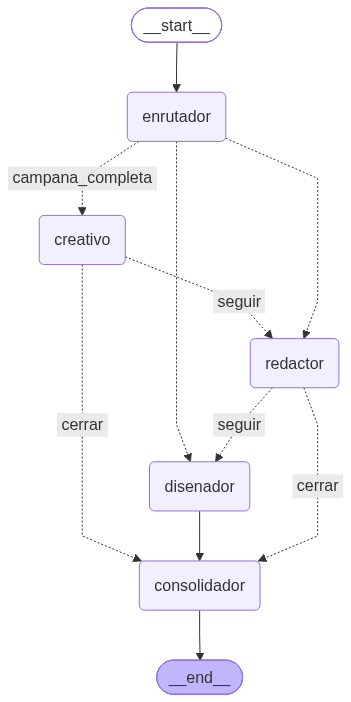

In [10]:
import os

from IPython.display import Image, display

try:
    display(Image(equipo_publicitario.get_graph().draw_mermaid_png()))
except Exception as error:
    # draw_mermaid_png() renderiza en el servicio mermaid.ink y necesita internet.
    # Desde mi WSL no hay salida a esa API, así que muestro el PNG ya generado.
    print(f"Sin acceso a mermaid.ink ({type(error).__name__}); uso el PNG guardado.")
    if os.path.exists("grafo_equipo_publicitario.png"):
        display(Image(filename="grafo_equipo_publicitario.png"))
    print(equipo_publicitario.get_graph().draw_mermaid())

### 8. Ruta 1 — campaña completa

El caso principal: el cliente pide la campaña de lanzamiento y el equipo entero trabaja en cadena.

In [11]:
from IPython.display import Markdown

pedido = (
    "Necesitamos la primera campaña de lanzamiento de Cafe.AI para redes sociales, "
    "con concepto, textos y arte."
)
estado = equipo_publicitario.invoke({"pedido": pedido})
Markdown(estado["entregable"])

[ENRUTADOR] ruta -> campana_completa (Lanzamiento de marca en redes sociales)
[CREATIVO] pensando el concepto de campaña...


[REDACTOR] escribiendo los copys...


[DISEÑADOR] definiendo dirección de arte...


[CONSOLIDADOR] armando el entregable...


# Campaña de lanzamiento — Cafe.AI

**Pedido del cliente:** Necesitamos la primera campaña de lanzamiento de Cafe.AI para redes sociales, con concepto, textos y arte.

**Ruta del equipo:** `campana_completa` — Lanzamiento de marca en redes sociales

**Modelo usado:** `llama3.2`

**Generado:** 2026-08-31 00:48:38

---

## Concepto (director creativo)

**Campana de Lanzamiento de Cafe.AI**

**Insight**
La mente creativa necesita un catalizador para desbloquear su potencial.

**Gran Idea**
Cafe.AI: donde la tecnología y el sabor se unen para impulsar tu creatividad.

**Eslogan**
"Conecta, crea e innova en cada taza"

**Hashtag**
#AIenAction

**Tono**
Cercano, humorístico y sin pretensiones.

**Ejes de Contenido**

1. **"La hora de la verdad"**: Presentamos a los creadores, innovadores y desarrolladores como personas que buscan impulsar su creatividad y conectar con la comunidad. En una escena de la vida cotidiana, mostramos cómo un café puede ser el catalizador para una idea brillante.
	* Imagen: Una persona sentada en un café, con una expresión de "¡Eureka!" mientras toma un sorbo del Café.AI
2. **"La inteligencia detrás del sabor"**: Introducimos la tecnología que hace que el Café.AI sea más que solo un buen café. Mostramos cómo la Inteligencia Artificial (IA) ayuda a nuestros baristas a crear recetas personalizadas y a mejorar la experiencia del cliente.
	* Imagen: Un barista trabajando en una máquina de barro, con una pantalla de computadora conectada mostrando datos y algoritmos que le ayudan a crear un sabor único
3. **"Un lugar para conectar"**: Mostramos a las personas que vienen al Café.AI como parte de su comunidad. La campana busca mostrar cómo el café es más que solo un lugar para tomar un café, sino un espacio para conectarse con otros y compartir ideas.
	* Imagen: Una mesa llena de personas sentadas, conversando y riendo mientras disfrutan de sus tazas de Café.AI

---

## Copys (redactor)

**Campana de Lanzamiento de Cafe.AI**

**Instagram**

* Gancho: "El catalizador para tus grandes ideas"
* Texto:
"¿Estás listo para conectar, crear e innovar en cada taza?
Ven a Cafe.AI y descubre cómo la tecnología y el sabor se unen para impulsar tu creatividad.
#AIenAction"
* CTA: "Visita nuestro sitio web y haz que te invite"
* Hashtags: #CafeAI #ConectaCreaInnova #IAenAction

**LinkedIn**

* Gancho: "La mente creativa necesita un catalizador"
* Texto:
"¿Sabes qué es lo que puede impulsar tu creatividad?
La combinación perfecta de tecnología y sabor. Descubre cómo Cafe.AI está revolucionando la forma en que nos conectamos con nuestra comunidad.
Visita nuestro sitio web para más información."
* CTA: "Descubre más sobre nosotros"
* Hashtags: #CafeAI #Innovación #Conexión

**TikTok**

* Gancho hablado: "¡Eureka! ¿Qué te hace saltar de emoción?"
* Guion:
"Escena 1: Una persona sentada en un café, con una expresión de '¡Eureka!' mientras toma un sorbo del Café.AI
Escena 2: Un barista trabajando en una máquina de barro, con una pantalla de computadora conectada mostrando datos y algoritmos que le ayudan a crear un sabor único
Escena 3: Una mesa llena de personas sentadas, conversando y riendo mientras disfrutan de sus tazas de Café.AI"
* CTA: "¡Visítanos en nuestro sitio web y haz que te invite!"
* Hashtags: #AIenAction #CafeAI #ConectaCreaInnova

**Arte**

* Imagen principal: Una persona sentada en un café, con una expresión de "¡Eureka!" mientras toma un sorbo del Café.AI
* Imagen de barista: Un barista trabajando en una máquina de barro, con una pantalla de computadora conectada mostrando datos y algoritmos que le ayudan a crear un sabor único
* Imagen de comunidad: Una mesa llena de personas sentadas, conversando y riendo mientras disfrutan de sus tazas de Café.AI

**Recomendaciones**

* Utilizar colores calientes y acogedores en la presentación para transmitir una sensación de comodidad y creatividad.
* Incluir iconos y gráficos que muestren la tecnología detrás del Café.AI, como circuitos electrónicos o diagramas de algoritmos.
* Utilizar música o sonidos que sean acordes con el tono cercano y humorístico de la campana.

---

## Dirección de arte (diseñador)

**Campana de Lanzamiento de Cafe.AI**

**Concepto Visual**
Una imagen cálida y acogedora que muestre a una persona sentada en un café, con una expresión de "¡Eureka!" mientras toma un sorbo del Café.AI. La iluminación sería suave y cálida, con tonos de rosa y naranja para transmitir una sensación de creatividad y inspiración.

**Paleta de Colores**

* #F7D2C4 (tono cálido y acogedor)
* #8B9467 (tono oscuro y tecnológico)
* #34A85A (tono verde y fresco)
* #FFC107 (tono naranja y vibrante)

**Tipografia**

* Título: Arial Black (fuente fuerte y impactante para el título)
* Texto: Open Sans (fuente legible y agradable para el texto)

**Composición**

* Imagen principal: Una persona sentada en un café, con una expresión de "¡Eureka!" mientras toma un sorbo del Café.AI.
* Título: "El catalizador para tus grandes ideas" en Arial Black
* Texto: "¿Estás listo para conectar, crear e innovar en cada taza? Ven a Cafe.AI y descubre cómo la tecnología y el sabor se unen para impulsar tu creatividad. #AIenAction" en Open Sans.
* CTA: "Visita nuestro sitio web y haz que te invite" en Arial Black
* Hashtags: #CafeAI #ConectaCreaInnova #IAenAction en Open Sans.

**Formatos**

* Instagram:
	+ Proporcion: 4:5
	+ Imagen ajustada a la proporcion
* LinkedIn:
	+ Proporcion: 16:9
	+ Imagen ajustada a la proporcion
* TikTok:
	+ Proporcion: 9:16
	+ Guion hablado y texto en movimiento
	+ Imagen principal: Una persona sentada en un café, con una expresión de "¡Eureka!" mientras toma un sorbo del Café.AI.
	+ Imagen de barista y mesa de comunidad ajustadas a la proporcion.

**Prompt de Imagen**

"Una imagen cálida y acogedora que muestre a una persona sentada en un café, con una expresión de '¡Eureka!' mientras toma un sorbo del Café.AI. La iluminación sería suave y cálida, con tonos de rosa y naranja para transmitir una sensación de creatividad y inspiración. Incluya iconos y gráficos que muestren la tecnología detrás del Café.AI, como circuitos electrónicos o diagramas de algoritmos."

### 9. Rutas puntuales — el enrutador ganándose el sueldo

Si el cliente ya tiene el concepto y solo quiere los copys, correr los tres roles es gastar tiempo y tokens. Estas tres corridas muestran que el enrutador manda cada pedido a un solo rol.

In [12]:
pedidos_puntuales = [
    "Solo necesito los copys para Instagram, ya tenemos el concepto",
    "Dame ideas y un eslogan para el lanzamiento",
    "Necesito la paleta de colores y el arte del post",
]

for p in pedidos_puntuales:
    print(f"\n>>> PEDIDO: {p}")
    resultado = equipo_publicitario.invoke({"pedido": p})
    print(f"--- ruta recorrida: {resultado['ruta']}")


>>> PEDIDO: Solo necesito los copys para Instagram, ya tenemos el concepto


[ENRUTADOR] ruta -> redactor (pedidos de contenido para redes sociales)
[REDACTOR] escribiendo los copys...


[CONSOLIDADOR] armando el entregable...
--- ruta recorrida: redactor

>>> PEDIDO: Dame ideas y un eslogan para el lanzamiento


[ENRUTADOR] ruta -> creativo (lanzamiento de campana en redes sociales)
[CREATIVO] pensando el concepto de campaña...


[CONSOLIDADOR] armando el entregable...
--- ruta recorrida: creativo

>>> PEDIDO: Necesito la paleta de colores y el arte del post


[ENRUTADOR] ruta -> disenador (paleta de colores y arte del post)
[DISEÑADOR] definiendo dirección de arte...


[CONSOLIDADOR] armando el entregable...
--- ruta recorrida: disenador


### 10. Qué aprendí y qué quedó pendiente

**Lo que funciona bien.** El enrutador con `with_structured_output` acertó las cuatro rutas en las pruebas, incluso con `llama3.2` (3.000 millones de parámetros, corriendo local). Clasificar es una tarea fácil para un modelo pequeño: elegir entre cuatro etiquetas, con el esquema de Pydantic obligando la forma de la respuesta.

**Dónde se ve el límite del modelo local.** Generar es harto más difícil que clasificar. Con `llama3.2`, los tres roles cumplen el encargo pero se salen del formato pedido (escriben `**Instagram**` en vez de `## Instagram`), agregan preámbulos que les pedí no poner ("Espero que esta propuesta sea de su agrado"), y el diseñador me entregó el prompt de imagen en español cuando lo pedí en inglés. En una corrida llegó a describir un *bar* con velas en vez de un café con laptops. Nada de esto es culpa del grafo: el grafo enrutó, encadenó y consolidó correctamente en todas las corridas. Por eso dejé el backend conmutable — el mismo grafo con Claude o con Gemma vía LM Studio entrega piezas mucho más publicables, como ya había medido en `TESTING_MODELOS_EQUIPO_EDITORIAL.md` de la Sesión 14.

**Lo que agregaría con más tiempo.** Un quinto rol *evaluador* que revise las piezas contra el brief y devuelva el trabajo al redactor si el copy inventa precios o promociones — es el patrón *evaluator-optimizer* de `intro.ipynb`, y es exactamente la pieza que le falta a este equipo para funcionar sin supervisión humana.